# Métodos aproximados de control en Aprendizaje por Refuerzo

En el notebook anterior trabajábamos con **métodos tabulares** (tabla \(Q(s,a)\)). Eso funciona cuando el número de estados es pequeño y discreto.

En este notebook pasamos a un entorno como **Acrobot-v1**, donde el estado es **continuo** (o de gran cardinalidad). En estos casos:

- Guardar una tabla \(Q(s,a)\) es inviable.
- Necesitamos **aproximación de funciones** para representar valores/políticas de forma compacta.

La idea general es aproximar una función valor-acción:

($
\hat{q}(s,a;\mathbf{w}) \approx q_\pi(s,a)
$)

donde \(\mathbf{w}\) son parámetros (pesos) de un aproximador (lineal o red neuronal).  
Esto es precisamente lo que se introduce en “Predicción/Control con aproximaciones”.

# 1. Reproducibilidad y configuración experimental

El notebook fija una semilla (`seed=42`) para asegurar que:

- NumPy genere la misma secuencia aleatoria.
- Gymnasium inicialice de forma controlada el entorno.
- El espacio de acciones/observaciones sea reproducible.

Esto es importante porque en RL el entrenamiento depende fuertemente de:
- la exploración,
- las trayectorias visitadas,
- y el ruido estocástico del entorno.

**Nota:** En entornos de control con aproximación, pequeñas diferencias iniciales pueden producir curvas distintas, por lo que controlar semillas mejora la comparabilidad experimental.

In [11]:
from src.agents import AgentDeepQLearning, AgentSemiGradientSARSAv2
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

seed = 200

# Fijamos la semilla para reproducibilidad
seed = 42
np.random.seed(seed)
np.random.default_rng(seed)

# Fijamos la semilla en Gymnasium
def make_env(env_name):
    env = gym.make(env_name, render_mode='None')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

n_episodes = 10000

# 2. Métricas registradas y qué significan

Se registran tres métricas para comparar agentes:

## (a) Proporción acumulada de éxitos
Mide la fracción de episodios completados con éxito:

($
\text{ratio}(t) = \frac{\sum_{i=1}^{t} \mathbb{1}(\text{éxito}_i)}{t}
$)

Sirve para ver **convergencia** y **estabilidad** de la política.

## (b) Longitud del episodio (número de pasos)
Indica la eficiencia de la política: si el agente aprende una estrategia mejor, normalmente necesita menos pasos.

## (c) Media acumulada del return
Aproxima el rendimiento esperado:

($
J(\pi) = \mathbb{E}[G_t]
$)


En tareas con penalización por paso, la mejora del return suele correlacionar con episodios más cortos.

Estas métricas permiten contrastar empíricamente lo esperado por la teoría de control en MDPs: una política mejor maximiza retorno y reduce comportamiento errático.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_success_ratio(final_results):
    plt.figure(figsize=(8, 4))
    
    # Iteramos sobre cada agente guardado en el diccionario
    for name, data in final_results.items():
        successes = np.array(data["list_stats_success"])
        cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)
        # Dibujamos la línea de este agente y le asignamos su nombre para la leyenda
        plt.plot(cumulative_ratio, label=name)

    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.legend() # <-- Muy importante para distinguir los colores
    plt.show()

def plot_episode_length(final_results):
    plt.figure(figsize=(10, 5))
    
    for name, data in final_results.items():
        y = np.array(data["episode_lengths"], dtype=float)
        x = np.arange(len(y))
        
        # Añadimos alpha=0.6 para dar cierta transparencia. 
        # Como los pasos (steps) oscilan mucho, si las líneas son opacas no se verá nada debajo.
        plt.plot(x, y, label=name, alpha=0.6)

    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_global_avg(final_results):
    plt.figure(figsize=(8, 4))
    
    for name, data in final_results.items():
        list_stats = data["list_stats"]
        indices = list(range(len(list_stats)))
        plt.plot(indices, list_stats, label=name)

    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.legend()
    plt.show()

# Opcional: Una función "wrapper" para llamar a las tres de golpe
def plot_all_results(final_results):
    plot_success_ratio(final_results)
    plot_episode_length(final_results)
    plot_global_avg(final_results)

# 3. Algoritmos comparados: SARSA semigradiente vs Deep Q-Learning

En este notebook se entrenan dos agentes:

- **SARSA Semigradiente (on-policy con aproximación)**
- **Deep Q-Learning (off-policy con red neuronal)**


## 3.1 SARSA Semigradiente (on-policy)

SARSA es un método TD on-policy. En su forma tabular:

($
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma Q(s',a') - Q(s,a)\right]
$)

En aproximación de funciones, ya no actualizamos una tabla, sino parámetros \(\mathbf{w}\).  
Se usa una actualización **semigradiente**:

($
\mathbf{w} \leftarrow \mathbf{w} + \alpha \, \delta \, \nabla_{\mathbf{w}} \hat{q}(s,a;\mathbf{w})
$)

donde el error TD es:

($
\delta = r + \gamma \hat{q}(s',a';\mathbf{w}) - \hat{q}(s,a;\mathbf{w})
$)

Se llama *semi-gradiente* porque el objetivo también depende de \(\mathbf{w}\), pero el gradiente se toma solo sobre la predicción actual.  
Esta formulación aparece en las transparencias de **control con aproximaciones**. 



## 3.2 Deep Q-Learning (off-policy)

Q-Learning, en su forma tabular, actualiza hacia el máximo:

($
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$)

En Deep Q-Learning se sustituye \(Q\) por una red neuronal \(\hat{q}(s,a;\mathbf{w})\).  
Conceptualmente sigue siendo una aproximación de:

- **Q-Learning semigradiente**
- usando un aproximador no lineal (red)

Deep Q-Learning es off-policy: puede aprender la política greedy objetivo aunque los datos provengan de una política exploratoria (ε-greedy).  
Esto suele acelerar el aprendizaje en muchos problemas, pero también puede introducir inestabilidad si no se controla bien la aproximación.


## 3.3 Por qué el bucle elige acción antes (detalle importante de SARSA)

En SARSA, el objetivo TD usa la **acción realmente ejecutada** en el siguiente estado (\(a'\)).  
Por eso el bucle del notebook:

1. elige \(a\) antes de entrar al while,
2. tras `update(...)` obtiene `next_action`,
3. avanza `state = next_state` y `action = next_action`.

Esto implementa literalmente el patrón SARSA:

($
(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})
$)

y lo diferencia de Q-Learning, donde el objetivo usa \(\max_{a'}\) en vez de la acción tomada. 

In [ ]:
# 2. Instanciamos nuestros agentes y entornos
envSarsaSemigrad = make_env("Acrobot-v1")
envDeepQLearning = make_env("Acrobot-v1")

agentSarsaSemigrad = AgentSemiGradientSARSAv2(envSarsaSemigrad, alpha=0.2, epsilon_decay=0.992)
# Asegúrate de que el nombre de la clase sea el correcto (AgentDeepQLearning)
agentDeepQLearning = AgentDeepQLearning(envDeepQLearning, epsilon=0.4, discount_factor=1.0)

step_display = n_episodes // 10 

# Agrupamos en lista para iterar
agents_and_envs = [
    ("Sarsa Semigradiente", agentSarsaSemigrad, envSarsaSemigrad),
    ("Deep QLearning", agentDeepQLearning, envDeepQLearning),
]

final_results = {}

# 3. Bucle de entrenamiento unificado
print(f"Iniciando entrenamiento de {len(agents_and_envs)} agentes...")

for episode in tqdm(range(n_episodes)):
    
    for name, agent, env in agents_and_envs:
        state, info = env.reset(seed=seed)
        done = False
        
        # --- CAMBIO CLAVE PARA SARSA ---
        # Elegimos la primera acción antes de entrar al bucle del episodio
        action = agent.get_action(state)
        
        while not done:
            # El entorno reacciona a la acción ya elegida
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # El método update debe devolver la SIGUIENTE acción (A')
            # En SARSA esto es obligatorio. En DQN, el update puede devolver agent.get_action(next_state)
            # Cambio rápido si no quieres tocar las clases:
            res = agent.update(state, action, next_state, reward, terminated, truncated, info)
            next_action = res if res is not None else agent.get_action(next_state)
                        
            # Transición de estado y acción
            state = next_state
            action = next_action 
            
            done = terminated or truncated
            
        # Feedback visual
        if episode % step_display == 0 and episode != 0:
            # He ajustado esto para que use list_stats si 'stats' no existe en DQN
            current_success = agent.list_stats_success[-1] if hasattr(agent, 'list_stats_success') else 0
            print(f"[{name}] Ep: {episode} | Success Rate: {current_success:.2f} | Eps: {agent.epsilon:.3f}")

# 4. Resultados finales
for name, agent, env in agents_and_envs:
    # Desempaquetamos los resultados (asegúrate de que DQN devuelva 4 valores en get_stats)
    results = agent.get_stats()
    
    final_results[name] = {
        "Q": results[0],
        "list_stats": results[1],
        "episode_lengths": results[2],
        "list_stats_success": results[3]
    }
    
    env.close()

print("Entrenamiento completado y entornos cerrados.")

Iniciando entrenamiento de 2 agentes...


  0%|          | 0/10000 [00:00<?, ?it/s]

 10%|█         | 1000/10000 [09:02<1:33:31,  1.60it/s]

[Sarsa Semigradiente] Ep: 1000 | Success Rate: 1.00 | Eps: 0.010


 10%|█         | 1001/10000 [09:03<1:31:38,  1.64it/s]

...

 50%|█████     | 5000/10000 [37:53<33:04,  2.52it/s]  

[Sarsa Semigradiente] Ep: 5000 | Success Rate: 1.00 | Eps: 0.010


 50%|█████     | 5001/10000 [37:54<33:50,  2.46it/s]

[Deep QLearning] Ep: 5000 | Success Rate: 1.00 | Eps: 0.033


 56%|█████▋    | 5629/10000 [41:48<33:10,  2.20it/s]

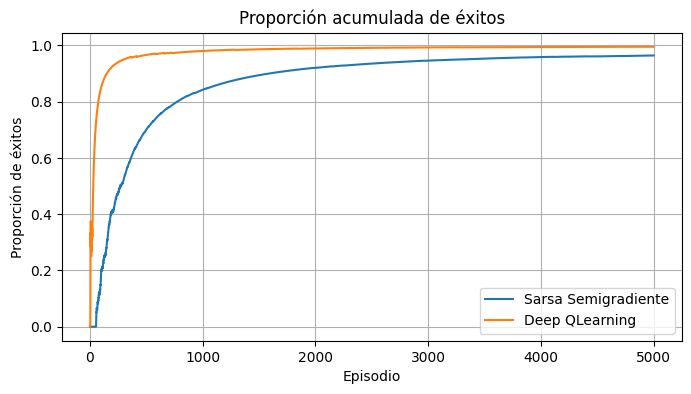

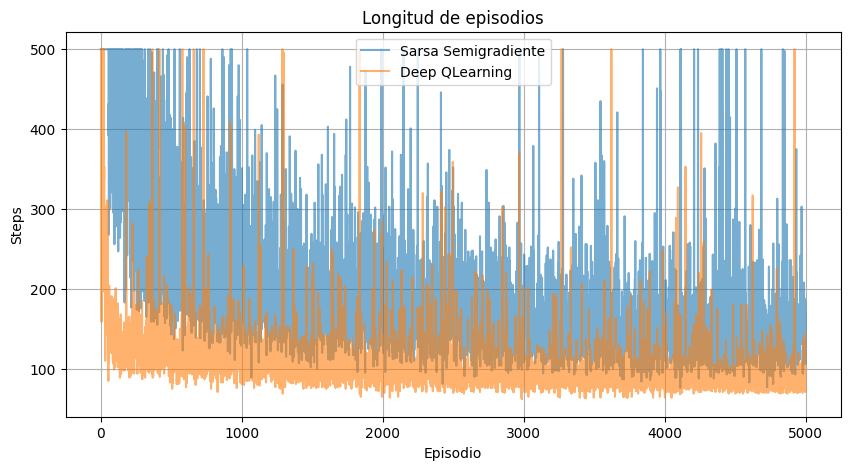

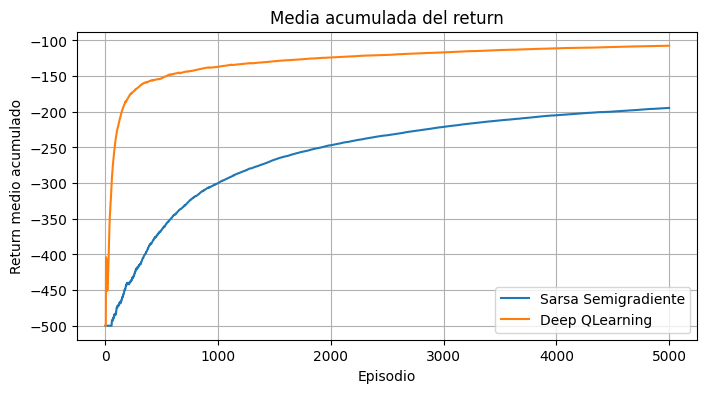

In [ ]:
plot_all_results(final_results)